## IMPORT LIBRARIES

In [80]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Statsmodels - Time Series Tools & Diagnostics
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL

# Scikit-learn - Model Evaluation & Validation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Suppress statistical test warning noise
warnings.filterwarnings("ignore")

# Set plot style and inline rendering
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## DATA IMPORT

In [81]:
# File paths
slcv_path = r"C:/Users/ADMIN/Desktop/MKP Group/Excel Database/SLCV_ALL.csv"
mhcv_path = r"C:/Users/ADMIN/Desktop/MKP Group/Excel Database/MHCV_ALL.csv"
dsr_path = r"C:/Users/ADMIN/Desktop/MKP Group/Excel Database/DSR Master.xlsx"

# Load datasets
slcv = pd.read_csv(slcv_path, low_memory=False)
mhcv = pd.read_csv(mhcv_path, low_memory=False)
dsr_master = pd.read_excel(dsr_path)

# Strip any leading/trailing whitespace from column names across all DataFrames
for df_temp in [slcv, mhcv, dsr_master]:
    df_temp.columns = df_temp.columns.str.strip()

# Verify initial shapes
print(f"SLCV Shape: {slcv.shape}")
print(f"MHCV Shape: {mhcv.shape}")
print(f"DSR Master Shape: {dsr_master.shape}")

SLCV Shape: (248362, 57)
MHCV Shape: (237661, 57)
DSR Master Shape: (1021, 12)


In [82]:
# Add source company identifier tags
slcv['Company'] = 'SLCV'
mhcv['Company'] = 'MHCV'

# Concatenate SLCV and MHCV datasets
slcv_mhcv = pd.concat([slcv, mhcv], ignore_index=True)

# Convert Final Amount to Lakhs
slcv_mhcv['Final Amount (in lakhs)'] = (slcv_mhcv['Final Amount'] / 100000).round(2)

# Ensure join keys are trimmed strings to avoid silent merge mismatches
slcv_mhcv['Account Code'] = slcv_mhcv['Account Code'].astype(str).str.strip()
dsr_master_clean = dsr_master[['Account_Code', 'DSR']].dropna(subset=['Account_Code']).copy()
dsr_master_clean['Account_Code'] = dsr_master_clean['Account_Code'].astype(str).str.strip()

# Deduplicate lookup table before merging
dsr_master_clean = dsr_master_clean.drop_duplicates(subset=['Account_Code'])

# Merge with DSR Master
slcv_mhcv = pd.merge(
    slcv_mhcv,
    dsr_master_clean,
    left_on='Account Code',
    right_on='Account_Code',
    how='left'
).drop(columns=['Account_Code'])

# Verify merge results
unmatched_count = slcv_mhcv['DSR'].isna().sum()
print(f"Total Rows: {len(slcv_mhcv):,}")
print(f"Unmatched DSR Records: {unmatched_count:,} ({(unmatched_count / len(slcv_mhcv)):.2%})")

Total Rows: 486,023
Unmatched DSR Records: 2,835 (0.58%)


In [83]:
# Data Export

# a = slcv_mhcv[slcv_mhcv['DSR'].isna()]
# a.to_excel('Missing DSR Name.xlsx', index=False)

# slcv_mhcv.to_excel('ALL_DATA.xlsx', index=False)

In [84]:
slcv_mhcv.head(5)

,TM Fiscal Year,BU,Region,State,Retailer District,City,Dealer,Dealer Code,Division,Partner Type,...,Volume in Liters,HSN Code,TCS Rate,Order Source,GSTIN,IRN#,Parent A/C Code,Company,Final Amount (in lakhs),DSR
0,2022-23,TMCV,West,Maharashtra,AHMADNAGAR,RAHATWADE,AUTO XPERTS-2087730,2087730,2087730-Parts-Ahmadnagar-AroXoa,Distributor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SLCV,0.00,NaN
1,2022-23,TMCV,West,Maharashtra,AHMADNAGAR,RAHATWADE,AUTO XPERTS-2087730,2087730,2087730-Parts-Ahmadnagar-AroXoa,Distributor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SLCV,0.00,NaN
2,2022-23,TMCV,West,Maharashtra,AHMADNAGAR,RAHATWADE,AUTO XPERTS-2087730,2087730,2087730-Parts-Ahmadnagar-AroXoa,Distributor,...,NaN,NaN,NaN,NaN,NaN,NaN,1-119BJGCR,SLCV,0.02,VIKAS
3,2022-23,TMCV,West,Maharashtra,AHMADNAGAR,RAHATWADE,AUTO XPERTS-2087730,2087730,2087730-Parts-Ahmadnagar-AroXoa,Distributor,...,NaN,NaN,NaN,NaN,NaN,NaN,1-119BJGCR,SLCV,0.03,VIKAS
4,2022-23,TMCV,West,Maharashtra,AHMADNAGAR,RAHATWADE,AUTO XPERTS-2087730,2087730,2087730-Parts-Ahmadnagar-AroXoa,Distributor,...,NaN,NaN,NaN,NaN,NaN,NaN,1-119BJGCR,SLCV,0.04,VIKAS


## Adding Segment Columns

In [85]:
# Clean string columns to prevent spaces from breaking equality checks
tm_pg = slcv_mhcv['TM Product Group- New'].astype(str).str.strip()
cv_hier = slcv_mhcv['CV Product Hierarchy'].astype(str).str.strip()
company = slcv_mhcv['Company'].astype(str).str.strip()
amount = slcv_mhcv['Final Amount']

# Common Product Groups (PG1 - PG5)
pg1_5_mask = tm_pg.isin(["PG1", "PG2", "PG3", "PG4", "PG5"])

# 1. SLCV PG1-PG5
slcv_mhcv['SLCV PG1-PG5'] = np.where(pg1_5_mask & (company == "SLCV"), amount, 0)

# 2. MHCV PG1-PG5
slcv_mhcv['MHCV PG1-PG5'] = np.where(pg1_5_mask & (company == "MHCV"), amount, 0)

# 3. PG6
slcv_mhcv['PG6'] = np.where((tm_pg == 'PG6') & (cv_hier != "DPCVDPG600UREA"), amount, 0)

# 4. DEF
slcv_mhcv['DEF'] = np.where((tm_pg == 'PG6') & (cv_hier == "DPCVDPG600UREA"), amount, 0)

# 5. TMGO
slcv_mhcv['TMGO'] = np.where(tm_pg == 'TMGO', amount, 0)

# 6. VCP
slcv_mhcv['VCP'] = np.where(tm_pg == 'Others', amount, 0)

# 7. Brake Liner (Ends with 'LIN' or 'LINER')
slcv_mhcv['BRK LIN'] = np.where(
    cv_hier.str.endswith('LIN', na=False) | cv_hier.str.endswith('LINER', na=False),
    amount,
    0
)

# 8. Filter (Ends with 'FIL')
slcv_mhcv['Filter'] = np.where(cv_hier.str.endswith('FIL', na=False), amount, 0)

# 9. Clutch (Contains 'CLD')
slcv_mhcv['Clutch'] = np.where(cv_hier.str.contains('CLD', case=False, na=False), amount, 0)

# Summary check of calculated category sums (in Lakhs)
category_cols = ['SLCV PG1-PG5', 'MHCV PG1-PG5', 'PG6', 'DEF', 'TMGO', 'VCP', 'BRK LIN', 'Filter', 'Clutch']
print("Category Totals (in Lakhs):")
print((slcv_mhcv[category_cols].sum() / 100000).round(2))

Category Totals (in Lakhs):
SLCV PG1-PG5     6212.10
MHCV PG1-PG5    13695.30
PG6               474.60
DEF              5606.08
TMGO              643.77
VCP                36.08
BRK LIN           515.90
Filter           2725.23
Clutch           5964.46
dtype: float64


In [86]:
slcv_mhcv.columns

Index(['TM Fiscal Year', 'BU', 'Region', 'State', 'Retailer District', 'City',
       'Dealer', 'Dealer Code', 'Division', 'Partner Type', 'Account Code',
       'Account Name', 'Account Type', 'Order Number', 'Order Date',
       'Channel Type', 'Invoice Number', 'Invoice Status', 'Invoice Date',
       'Invoice Value', 'Part Number', 'Discount Type', 'Part Description',
       'CV Product Hierarchy', 'TM Product Group- New', 'Unit',
       'Sold Quantity', 'TM Part Indicator', 'DSR First Name', 'DSR Last Name',
       'DSR Login', 'Value', 'Base Discount %', 'Scheme Discount %',
       'Discount %', 'Discount', 'Header Discount', 'Distr Discount %',
       'TML Discount %', 'Cash Discount', 'Tax Amount After Discount',
       'Order Item Discount %', 'Order Part Discount %', 'Taxable Amount',
       'Invoice Amount', 'Final Amount', 'MPG (discount%)', 'NTA', 'Row WID',
       'Volume Per Unit', 'Volume in Liters', 'HSN Code', 'TCS Rate',
       'Order Source', 'GSTIN', 'IRN#', 'Paren

## DATA VALIDATION & PREPARATION

### 1. Datetime Formatting and Sorting

In [87]:
slcv_mhcv.columns

Index(['TM Fiscal Year', 'BU', 'Region', 'State', 'Retailer District', 'City',
       'Dealer', 'Dealer Code', 'Division', 'Partner Type', 'Account Code',
       'Account Name', 'Account Type', 'Order Number', 'Order Date',
       'Channel Type', 'Invoice Number', 'Invoice Status', 'Invoice Date',
       'Invoice Value', 'Part Number', 'Discount Type', 'Part Description',
       'CV Product Hierarchy', 'TM Product Group- New', 'Unit',
       'Sold Quantity', 'TM Part Indicator', 'DSR First Name', 'DSR Last Name',
       'DSR Login', 'Value', 'Base Discount %', 'Scheme Discount %',
       'Discount %', 'Discount', 'Header Discount', 'Distr Discount %',
       'TML Discount %', 'Cash Discount', 'Tax Amount After Discount',
       'Order Item Discount %', 'Order Part Discount %', 'Taxable Amount',
       'Invoice Amount', 'Final Amount', 'MPG (discount%)', 'NTA', 'Row WID',
       'Volume Per Unit', 'Volume in Liters', 'HSN Code', 'TCS Rate',
       'Order Source', 'GSTIN', 'IRN#', 'Paren

In [88]:
Date_Col = 'Invoice Date'
Target_Col = 'Final Amount (in lakhs)'

# Convert Invoice Date to datetime
slcv_mhcv[Date_Col] = pd.to_datetime(slcv_mhcv[Date_Col], errors='coerce')

# Check for invalid dates
invalid_dates = slcv_mhcv[slcv_mhcv[Date_Col].isna()]
invalid_count = len(invalid_dates)

print(f"Invalid Date Count (NaT): {invalid_count:,}")

# Drop rows with invalid dates if present to ensure uninterrupted time-series processing
if invalid_count > 0:
    slcv_mhcv = slcv_mhcv.dropna(subset=[Date_Col]).copy()
    print(f"Dropped {invalid_count:,} rows with missing dates.")

# Output dataset time horizon
min_date = slcv_mhcv[Date_Col].min().strftime('%Y-%m-%d')
max_date = slcv_mhcv[Date_Col].max().strftime('%Y-%m-%d')
print(f"Date Horizon: {min_date} to {max_date}")

Invalid Date Count (NaT): 0
Date Horizon: 2022-04-07 to 2026-09-28


In [89]:
'''
# Datetime Formatting and Sorting Conslusion - 
Invalid Date and Null delivery date is zero. No required for further correcting or preparation.

'''

'\n# Datetime Formatting and Sorting Conslusion - \nInvalid Date and Null delivery date is zero. No required for further correcting or preparation.\n\n'

### 2. Handing Duplicates & Aggregation

In [90]:
# Check transaction density per date
total_transactions = len(slcv_mhcv)
unique_dates = slcv_mhcv[Date_Col].nunique()
print(f"Total Transactions: {total_transactions:,}")
print(f"Unique Invoice Dates: {unique_dates:,}")

# List all numeric target and category columns to aggregate
category_cols = [
    Target_Col, 'SLCV PG1-PG5', 'MHCV PG1-PG5', 
    'PG6', 'DEF', 'TMGO', 'VCP', 'BRK LIN', 'Filter', 'Clutch'
]

# 1. Daily Aggregation
Invoice_Date_Aggregate = (
    slcv_mhcv.groupby(Date_Col)[category_cols]
    .sum()
    .reset_index()
)

# 2. Monthly Resampling (Monthly Start 'MS')
Invoice_Month_Aggregate = (
    Invoice_Date_Aggregate.set_index(Date_Col)
    .resample('MS')[category_cols]
    .sum()
    .reset_index()
)

# Sort chronologically and verify output
Invoice_Month_Aggregate = Invoice_Month_Aggregate.sort_values(by=Date_Col).reset_index(drop=True)

print(f"\nMonthly Resampled Dataset Shape: {Invoice_Month_Aggregate.shape}")
print(f"Null Values in Monthly Data:\n{Invoice_Month_Aggregate.isna().sum()}")

Invoice_Month_Aggregate.head()

Total Transactions: 486,023
Unique Invoice Dates: 1,432

Monthly Resampled Dataset Shape: (54, 11)
Null Values in Monthly Data:
Invoice Date               0
Final Amount (in lakhs)    0
SLCV PG1-PG5               0
MHCV PG1-PG5               0
PG6                        0
DEF                        0
TMGO                       0
VCP                        0
BRK LIN                    0
Filter                     0
Clutch                     0
dtype: int64


,Invoice Date,Final Amount (in lakhs),SLCV PG1-PG5,MHCV PG1-PG5,PG6,DEF,TMGO,VCP,BRK LIN,Filter,Clutch
0,2022-04-01,354.22,5.971985e+06,2.022666e+07,59281.320327,9.196235e+06,0.0,336.600010,269055.330613,1.725634e+06,7.493727e+06
1,2022-05-01,416.40,7.484521e+06,2.253601e+07,149704.700218,1.130685e+07,0.0,194190.168744,250253.488348,3.820927e+06,1.007645e+07
2,2022-06-01,433.61,9.570352e+06,2.470449e+07,435197.734475,8.621780e+06,0.0,90914.500009,313721.528248,3.251478e+06,1.227658e+07
3,2022-07-01,356.43,7.683546e+06,1.819514e+07,133881.199402,9.563444e+06,0.0,122568.280014,358937.095971,2.707011e+06,9.600082e+06
4,2022-08-01,415.63,9.143138e+06,2.250490e+07,65381.399403,9.688822e+06,0.0,219901.110017,425166.034064,4.136923e+06,9.217680e+06


### 3. Category wise / Segment Wise Outlier Finding
##### We are not applying Outlier Capping for financal data, because different products are having different Rate/value. Capping will lead wrong revenue, Category wise sales conparison, etc.

### 4. Statistical Stationarity Testing (ADF Test) 
##### Stationarity (constant mean and variance over time) is a strict requirement for classical statistical models like ARIMA.

=== Stationarity Analysis: Monthly Revenue (Raw) ===
ADF Statistic : -0.0178 | p-value: 0.9570
KPSS Statistic: 0.8297 | p-value: 0.0100
Result: Series is NON-STATIONARY (Differencing recommended)

=== Stationarity Analysis: 1st Order Differenced Monthly Revenue ===
ADF Statistic : -7.3240 | p-value: 0.0000
KPSS Statistic: 0.3323 | p-value: 0.1000
Result: Series is strictly STATIONARY



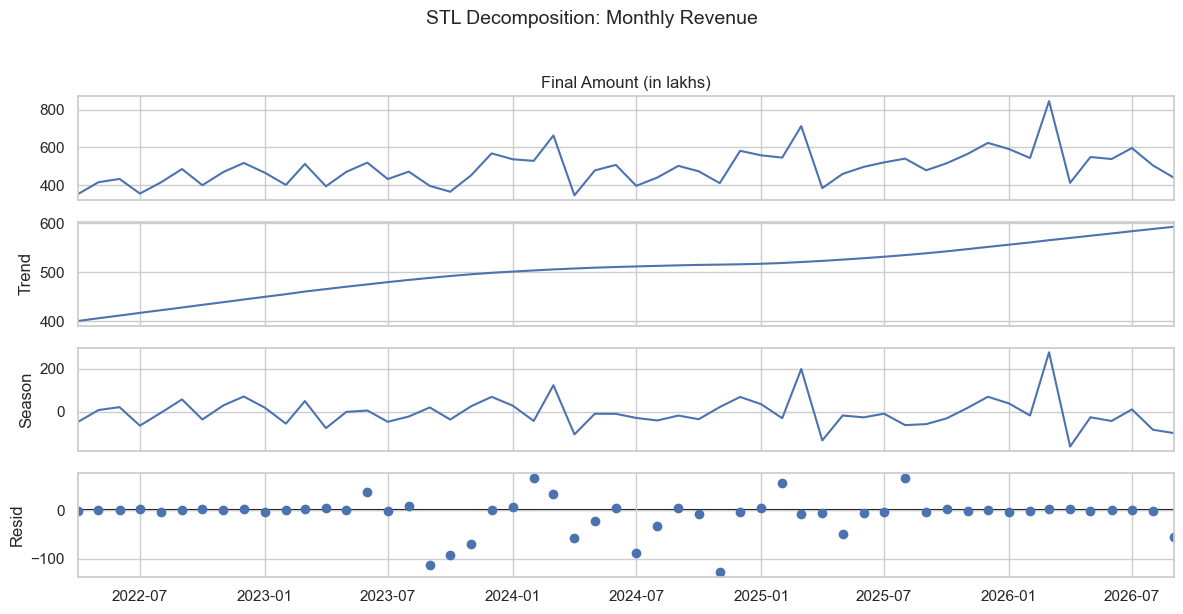

In [91]:
# 1. Dual Stationarity Test Function (ADF + KPSS)
def check_stationarity(series, title='Time Series'):
    print(f'=== Stationarity Analysis: {title} ===')
    clean_series = series.dropna()

    # Augmented Dickey-Fuller (ADF) Test
    adf_result = adfuller(clean_series)
    adf_stat, adf_p = adf_result[0], adf_result[1]
    
    # KPSS Test
    kpss_result = kpss(clean_series, regression='c', nlags="auto")
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]

    print(f'ADF Statistic : {adf_stat:.4f} | p-value: {adf_p:.4f}')
    print(f'KPSS Statistic: {kpss_stat:.4f} | p-value: {kpss_p:.4f}')

    if adf_p < 0.05 and kpss_p >= 0.05:
        print('Result: Series is strictly STATIONARY\n')
    elif adf_p >= 0.05:
        print('Result: Series is NON-STATIONARY (Differencing recommended)\n')
    else:
        print('Result: Series exhibits non-stationary trend or structural shift\n')

# 2. Stationarity Tests on Monthly Data
check_stationarity(Invoice_Month_Aggregate[Target_Col], 'Monthly Revenue (Raw)')

# 1st Order Differenced Series Test
Invoice_Month_Aggregate['Target_Diff_1'] = Invoice_Month_Aggregate[Target_Col].diff()
check_stationarity(Invoice_Month_Aggregate['Target_Diff_1'], '1st Order Differenced Monthly Revenue')

# 3. STL Decomposition (Seasonal-Trend decomposition using LOESS)
stl_data = Invoice_Month_Aggregate.set_index('Invoice Date')[Target_Col]

# Ensure at least 2 full seasonal cycles exist for period=12
if len(stl_data) >= 24:
    stl = STL(stl_data, period=12, robust=True)
    res = stl.fit()
    fig = res.plot()
    fig.suptitle('STL Decomposition: Monthly Revenue', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Dataset has {len(stl_data)} months. STL decomposition with period=12 requires >= 24 months.")

## ACF & PACF

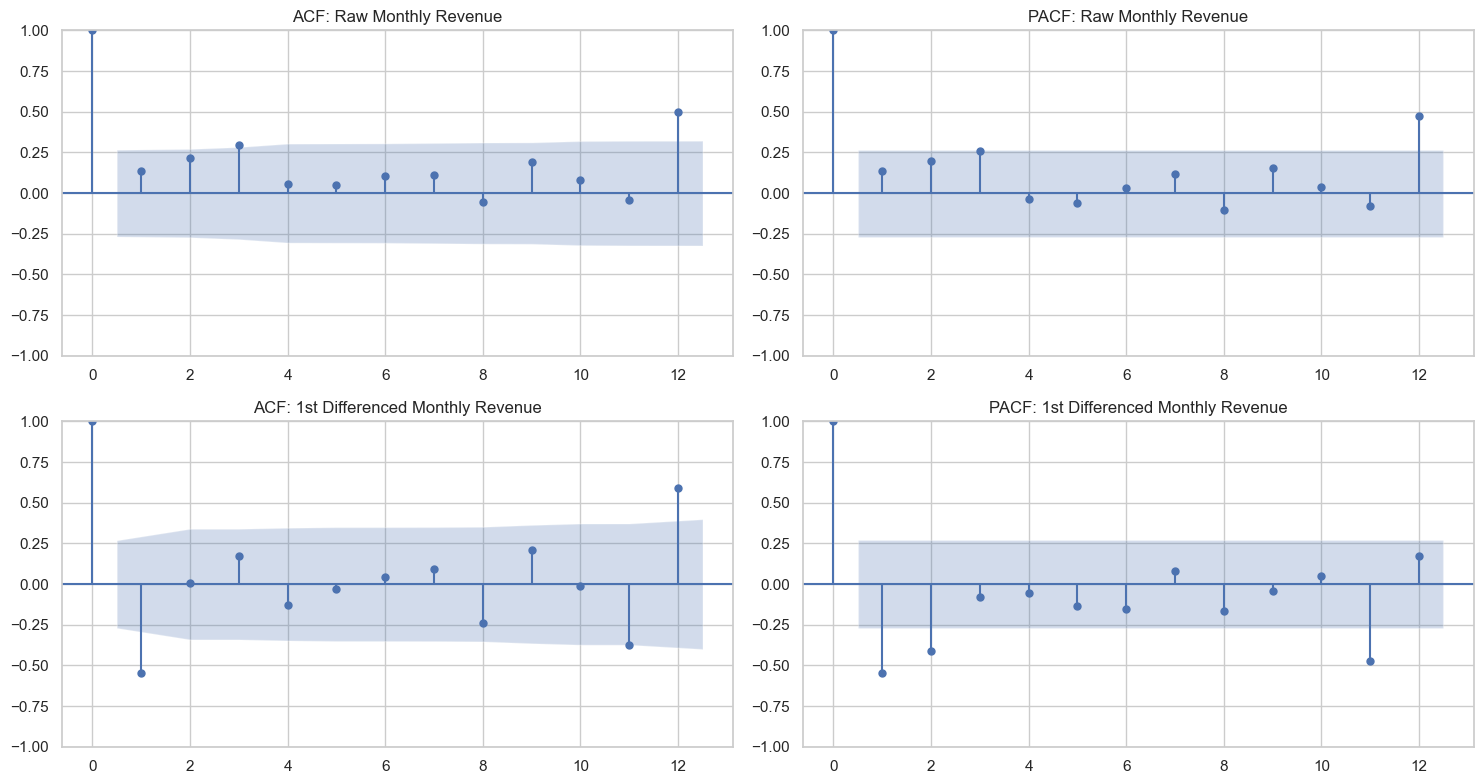

In [92]:
# Dynamic lag count calculation to prevent sample size errors
n_obs = len(Invoice_Month_Aggregate)
max_lags = min(12, int(n_obs / 2) - 1)

# Set up 2x2 subplot layout: Raw vs. 1st Differenced ACF/PACF
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# 1. Raw Monthly Revenue ACF & PACF
plot_acf(
    Invoice_Month_Aggregate[Target_Col].dropna(),
    lags=max_lags,
    ax=axes[0, 0],
    title='ACF: Raw Monthly Revenue'
)
plot_pacf(
    Invoice_Month_Aggregate[Target_Col].dropna(),
    lags=max_lags,
    ax=axes[0, 1],
    title='PACF: Raw Monthly Revenue'
)

# 2. 1st Differenced Monthly Revenue ACF & PACF
plot_acf(
    Invoice_Month_Aggregate['Target_Diff_1'].dropna(),
    lags=max_lags,
    ax=axes[1, 0],
    title='ACF: 1st Differenced Monthly Revenue'
)
plot_pacf(
    Invoice_Month_Aggregate['Target_Diff_1'].dropna(),
    lags=max_lags,
    ax=axes[1, 1],
    title='PACF: 1st Differenced Monthly Revenue'
)

plt.tight_layout()
plt.show()

                                     SARIMAX Results                                      
Dep. Variable:            Final Amount (in lakhs)   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -114.514
Date:                            Tue, 29 Sep 2026   AIC                            239.027
Time:                                    17:06:19   BIC                            244.250
Sample:                                04-01-2022   HQIC                           240.161
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0088      0.383      0.023      0.982      -0.741       0.759
ma.L1         -0.8469      0.298   

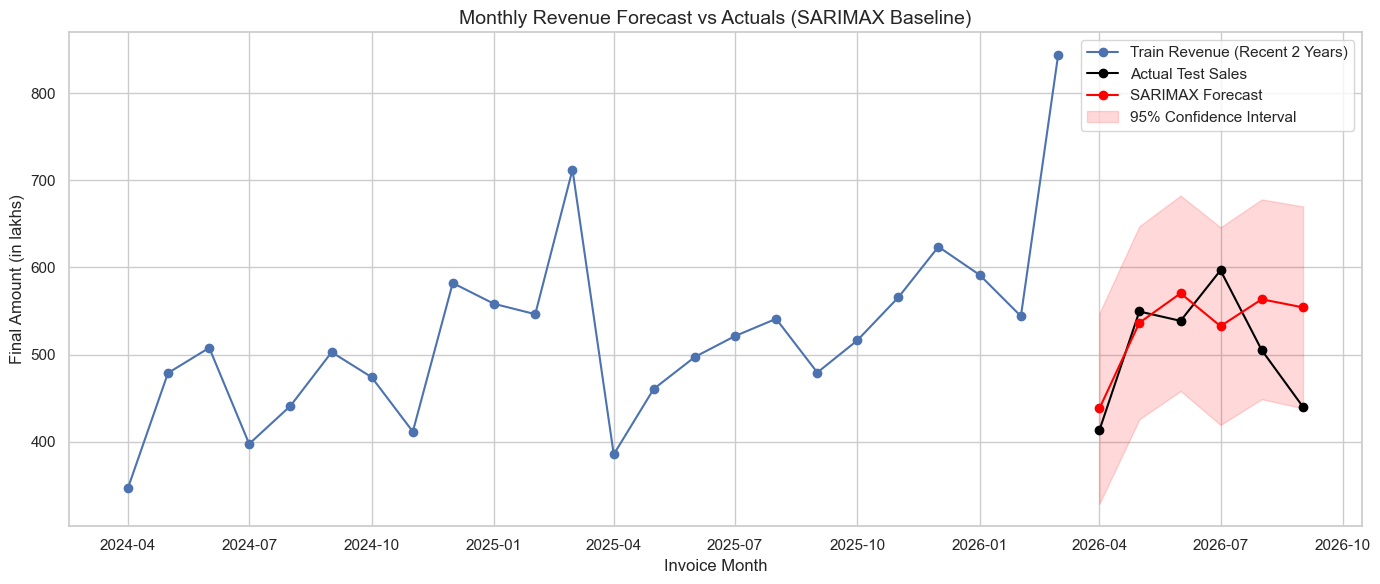

In [93]:
# 1. Time-Based Train/Test Split (Hold out last 6 months for testing)
TEST_MONTHS = 6

ts_data = Invoice_Month_Aggregate.set_index('Invoice Date')[Target_Col].asfreq('MS')

train = ts_data.iloc[:-TEST_MONTHS]
test = ts_data.iloc[-TEST_MONTHS:]

# 2. Fit SARIMAX Model on Monthly Data
# Order: (p=1, d=1, q=1), Seasonal Order: (P=1, D=1, Q=1, s=12)
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

# 3. Out-of-Sample Forecasting
forecast = results.get_forecast(steps=TEST_MONTHS)
forecast_df = forecast.conf_int()
forecast_df['predictions'] = forecast.predicted_mean

# Calculate Validation Metrics
y_true = test.values
y_pred = forecast_df['predictions'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("\n=== SARIMAX Validation Metrics (Last 6 Months) ===")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE : {mae:,.2f}")
print(f"MAPE: {mape:.2%}")

# 4. Visualization
plt.figure(figsize=(14, 6))
plt.plot(train.index[-24:], train.values[-24:], label='Train Revenue (Recent 2 Years)', marker='o')
plt.plot(test.index, test.values, label='Actual Test Sales', marker='o', color='black')
plt.plot(test.index, forecast_df['predictions'], label='SARIMAX Forecast', marker='o', color='red')

plt.fill_between(
    test.index,
    forecast_df.iloc[:, 0],
    forecast_df.iloc[:, 1],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast vs Actuals (SARIMAX Baseline)', fontsize=14)
plt.xlabel('Invoice Month')
plt.ylabel('Final Amount (in lakhs)')
plt.legend()
plt.tight_layout()
plt.show()

Training Period: 2022-04 to 2026-03 (48 months)
Testing Period : 2026-04 to 2026-09 (6 months)
                                     SARIMAX Results                                      
Dep. Variable:            Final Amount (in lakhs)   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -114.344
Date:                            Tue, 29 Sep 2026   AIC                            246.687
Time:                                    17:06:20   BIC                            256.088
Sample:                                04-01-2022   HQIC                           248.727
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Days_In_Month

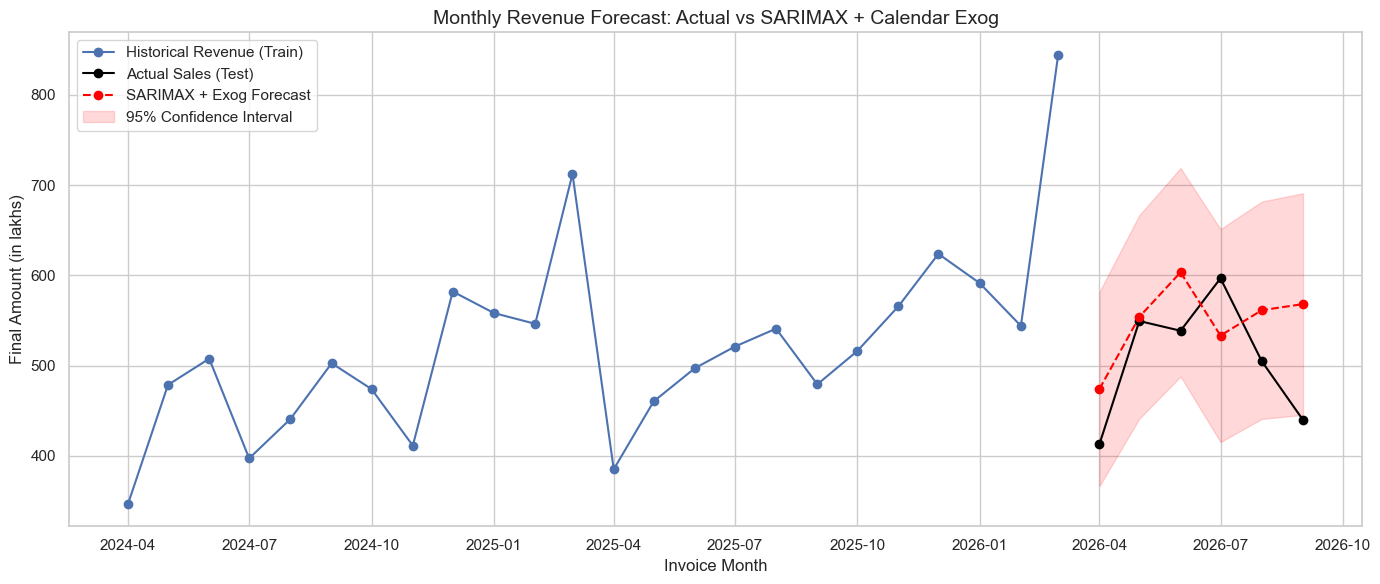

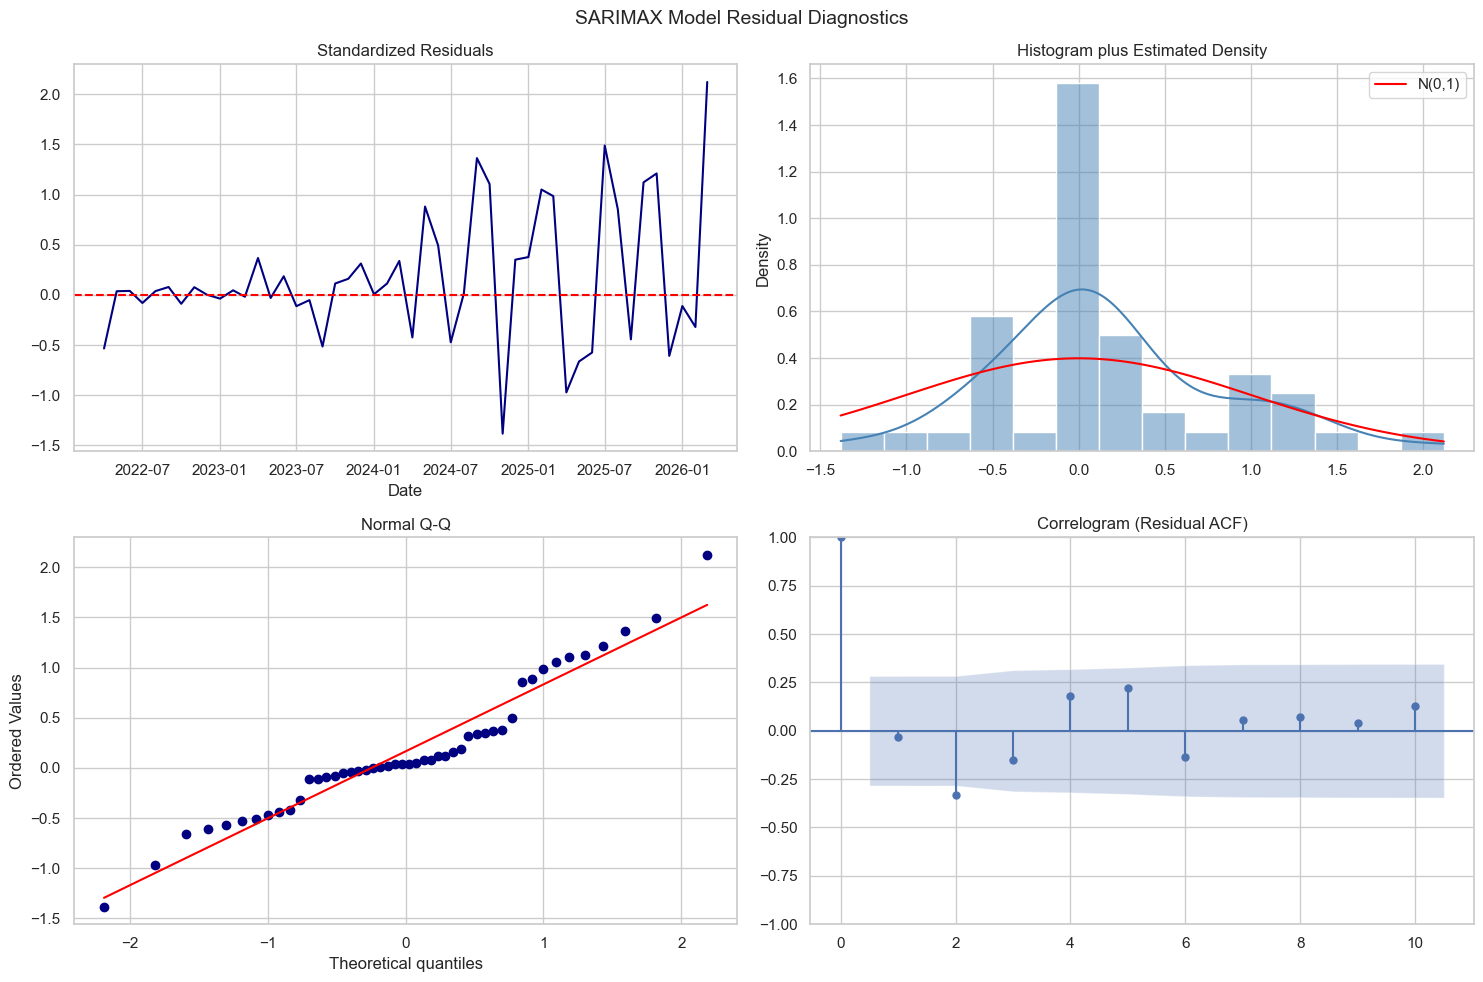

In [94]:
# 1. Feature Engineering (Monthly Calendar & Operational Exogenous Variables)
df_monthly = Invoice_Month_Aggregate.copy()

df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
df_monthly['Quarter'] = df_monthly['Invoice Date'].dt.quarter
df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month

# Cyclical Encoding for Monthly Seasonality
df_monthly['Sin_Month'] = np.sin(2 * np.pi * df_monthly['Month'] / 12)
df_monthly['Cos_Month'] = np.cos(2 * np.pi * df_monthly['Month'] / 12)

# Business Days (Working days per month)
df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

# Set Date Index
df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')

EXOG_COLS = ['Days_In_Month', 'Business_Days', 'Sin_Month', 'Cos_Month']

# 2. Time-Based Train/Test Split (Hold out last 6 months)
TEST_MONTHS = 6

train = df_monthly.iloc[:-TEST_MONTHS]
test = df_monthly.iloc[-TEST_MONTHS:]

print(f"Training Period: {train.index.min().strftime('%Y-%m')} to {train.index.max().strftime('%Y-%m')} ({len(train)} months)")
print(f"Testing Period : {test.index.min().strftime('%Y-%m')} to {test.index.max().strftime('%Y-%m')} ({len(test)} months)")

# 3. Fit SARIMAX(1,1,1)(1,1,1,12) with Exogenous Features
model = SARIMAX(
    train[Target_Col],
    exog=train[EXOG_COLS],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)
print(model_fit.summary())

# 4. Out-of-Sample Forecast
forecast_results = model_fit.get_forecast(steps=TEST_MONTHS, exog=test[EXOG_COLS])
forecast_df = forecast_results.conf_int()
forecast_df['Predictions'] = forecast_results.predicted_mean

# Performance Metrics Calculation
y_true = test[Target_Col].values
y_pred = forecast_df['Predictions'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100

print('\n=== SARIMAX + Exogenous Performance Metrics ===')
print(f'RMSE : {rmse:,.2f} lakhs')
print(f'MAE  : {mae:,.2f} lakhs')
print(f'MAPE : {mape:.2%}')
print(f'wMAPE: {wmape:.2f}%')

# 5. Visualization: Actual vs Forecast
plt.figure(figsize=(14, 6))
plt.plot(train.index[-24:], train[Target_Col].tail(24), label='Historical Revenue (Train)', marker='o')
plt.plot(test.index, test[Target_Col], label='Actual Sales (Test)', marker='o', color='black')
plt.plot(test.index, forecast_df['Predictions'], label='SARIMAX + Exog Forecast', marker='o', color='red', linestyle='--')

plt.fill_between(
    test.index,
    forecast_df.iloc[:, 0],
    forecast_df.iloc[:, 1],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast: Actual vs SARIMAX + Calendar Exog', fontsize=14)
plt.xlabel('Invoice Month')
plt.ylabel('Final Amount (in lakhs)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 6. Custom Residual Diagnostics (Bypasses plot_diagnostics sample size check)
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

# Extract standardized residuals
residuals = model_fit.filter_results.standardized_forecasts_error[0]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Standardized Residuals
axes[0, 0].plot(train.index, residuals, color='navy')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Standardized Residuals')
axes[0, 0].set_xlabel('Date')

# Plot 2: Histogram + Normal KDE Fit
sns.histplot(residuals, kde=True, ax=axes[0, 1], stat="density", color='steelblue')
x_axis = np.linspace(min(residuals), max(residuals), 100)
axes[0, 1].plot(x_axis, stats.norm.pdf(x_axis, 0, 1), color='red', label='N(0,1)')
axes[0, 1].set_title('Histogram plus Estimated Density')
axes[0, 1].legend()

# Plot 3: Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_color('navy')
axes[1, 0].get_lines()[1].set_color('red')
axes[1, 0].set_title('Normal Q-Q')

# Plot 4: Correlogram (ACF of Residuals)
plot_acf(residuals, ax=axes[1, 1], lags=min(10, len(residuals) // 2 - 1), title='Correlogram (Residual ACF)')

plt.suptitle('SARIMAX Model Residual Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

=== Out-of-Sample Future Monthly Revenue Forecast ===
        Month  Predicted Revenue (Lakhs)  Lower 95% CI  Upper 95% CI
 October 2026                     538.98        426.62        651.35
November 2026                     551.80        438.63        664.97
December 2026                     616.70        502.79        730.61
 January 2027                     601.33        486.73        715.92
February 2027                     550.28        435.05        665.51
   March 2027                     765.07        649.25        880.89


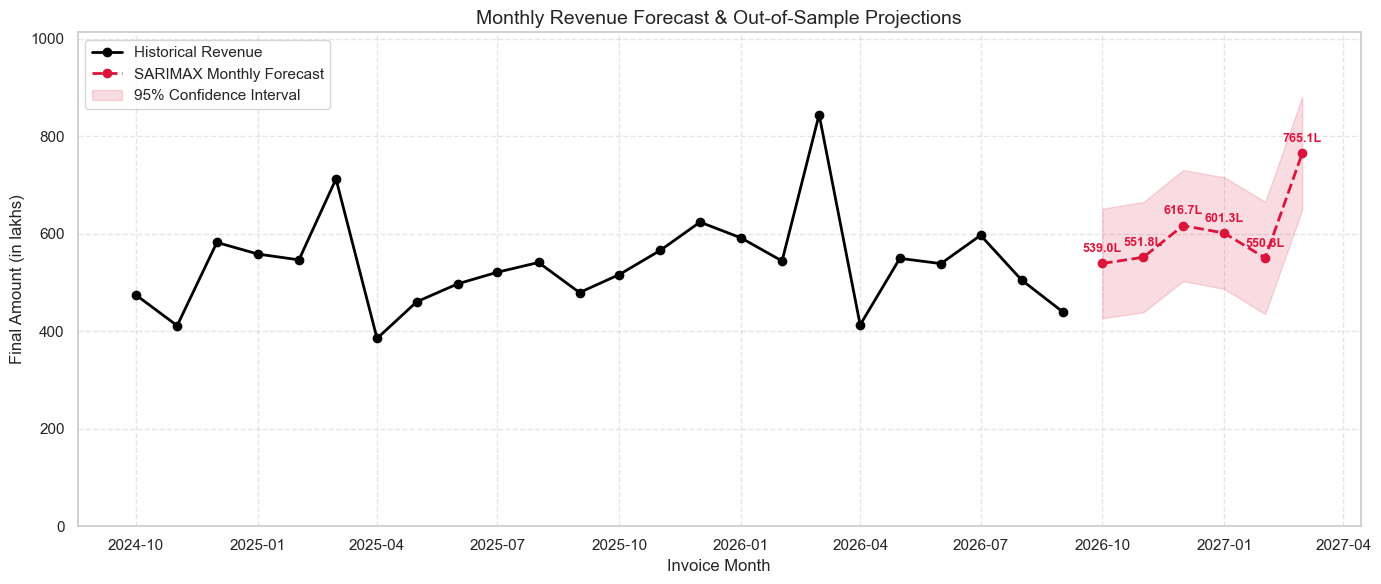

In [95]:
# 1. Dataset Preparation & Feature Engineering
df_monthly = Invoice_Month_Aggregate.copy()
df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month

# Calendar exogenous features (Drop ill-conditioned Sin/Cos to avoid numerical explosion)
df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

# Set Monthly Start Frequency
df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')

EXOG_COLS = ['Days_In_Month', 'Business_Days']

# 2. Fit Stable SARIMAX Model on Full Historical Data
full_model = SARIMAX(
    df_monthly[Target_Col],
    exog=df_monthly[EXOG_COLS],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
)

full_model_fit = full_model.fit(disp=False)

# 3. Construct Exogenous Matrix for Future Forecast Horizon (Next 6 Months)
FORECAST_HORIZON_MONTHS = 6
last_date = df_monthly.index.max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=FORECAST_HORIZON_MONTHS, freq='MS')

future_exog_df = pd.DataFrame({'Invoice Date': future_dates})
future_exog_df['Month'] = future_exog_df['Invoice Date'].dt.month
future_exog_df['Days_In_Month'] = future_exog_df['Invoice Date'].dt.days_in_month
future_exog_df['Business_Days'] = future_exog_df['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

future_exog = future_exog_df.set_index('Invoice Date')[EXOG_COLS]

# 4. Generate Out-of-Sample Forecast
forecast = full_model_fit.get_forecast(steps=FORECAST_HORIZON_MONTHS, exog=future_exog)
forecast_df = forecast.conf_int()
forecast_df['Forecast_Revenue_Lakhs'] = forecast.predicted_mean

# Clip negative lower bounds to 0 for realistic revenue plotting
lower_ci = np.maximum(0, forecast_df.iloc[:, 0].values)
upper_ci = forecast_df.iloc[:, 1].values

# Format Forecast Table
forecast_table = pd.DataFrame({
    'Month': future_dates.strftime('%B %Y'),
    'Predicted Revenue (Lakhs)': forecast_df['Forecast_Revenue_Lakhs'].values.round(2),
    'Lower 95% CI': lower_ci.round(2),
    'Upper 95% CI': upper_ci.round(2)
})

print("=== Out-of-Sample Future Monthly Revenue Forecast ===")
print(forecast_table.to_string(index=False))

# 5. Plot Full Historical Trend & Future Monthly Forecast
plt.figure(figsize=(14, 6))

# Plot Recent Historical Monthly Sales (Last 24 Months)
historical_subset = df_monthly[Target_Col].tail(24)
plt.plot(historical_subset.index, historical_subset.values, label='Historical Revenue', color='black', marker='o', linewidth=2)

# Plot Forecast Line
plt.plot(future_dates, forecast_df['Forecast_Revenue_Lakhs'], label='SARIMAX Monthly Forecast', color='crimson', linestyle='--', marker='o', linewidth=2)

# Add Data Labels for Predictions
for x, y in zip(future_dates, forecast_df['Forecast_Revenue_Lakhs']):
    plt.annotate(
        f'{y:.1f}L',
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        color='crimson',
        fontweight='bold'
    )

# Confidence Interval
plt.fill_between(
    future_dates,
    lower_ci,
    upper_ci,
    color='crimson',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast & Out-of-Sample Projections', fontsize=14)
plt.xlabel('Invoice Month', fontsize=12)
plt.ylabel('Final Amount (in lakhs)', fontsize=12)

# Set realistic y-axis limits matching data scale
y_max = max(historical_subset.max(), upper_ci.max()) * 1.15
plt.ylim(bottom=0, top=y_max)

plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

=== Monthly Actual vs Model Forecast Comparison ===
   Month  Actual Revenue (Lakhs)  Model Forecast (Lakhs)  Variance (Lakhs)  Variance (%)
Apr 2026                  413.00                  474.12             61.12         14.80
May 2026                  549.44                  554.01              4.57          0.83
Jun 2026                  538.67                  603.44             64.77         12.02
Jul 2026                  596.76                  533.32            -63.44        -10.63
Aug 2026                  504.98                  561.42             56.44         11.18
Sep 2026                  439.85                  568.19            128.34         29.18


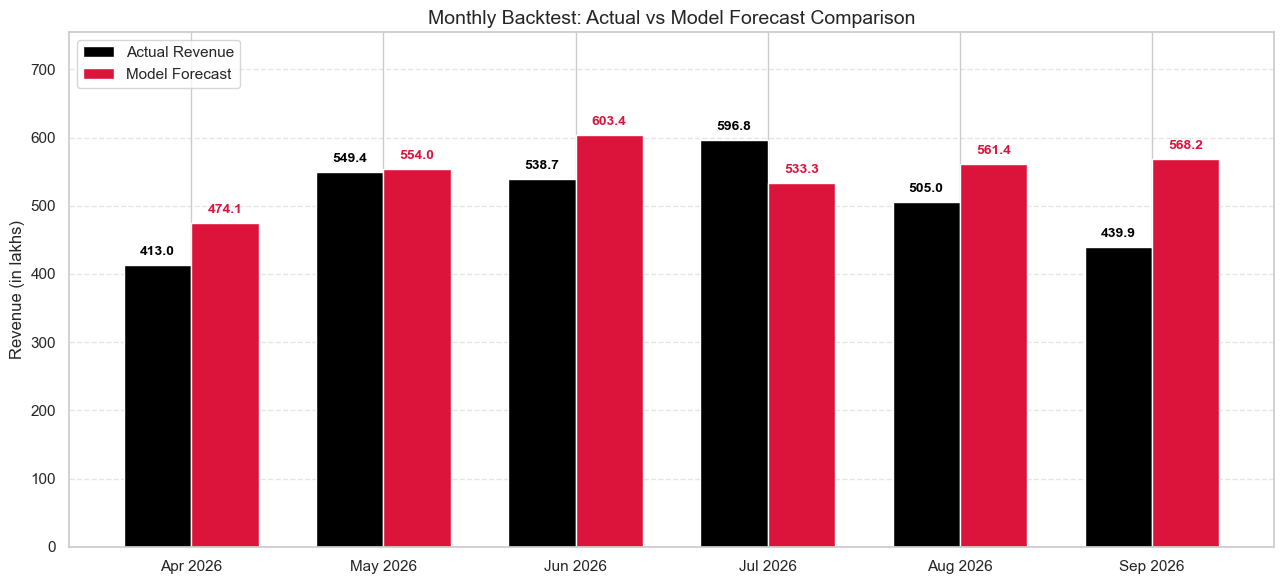

In [96]:
# 1. Dataset Preparation & Exogenous Feature Alignment
df_monthly = Invoice_Month_Aggregate.copy()
df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month
df_monthly['Sin_Month'] = np.sin(2 * np.pi * df_monthly['Month'] / 12)
df_monthly['Cos_Month'] = np.cos(2 * np.pi * df_monthly['Month'] / 12)

df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')
EXOG_COLS = ['Days_In_Month', 'Business_Days', 'Sin_Month', 'Cos_Month']

# 2. Time Split for Model Fit & Backtest Evaluation (Hold out last 6 months)
EVAL_MONTHS = 6
train_df = df_monthly.iloc[:-EVAL_MONTHS]
test_df = df_monthly.iloc[-EVAL_MONTHS:]

# Fit SARIMAX Model
model = SARIMAX(
    train_df[Target_Col],
    exog=train_df[EXOG_COLS],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

# 3. Predict Out-of-Sample Evaluation Period
forecast = model_fit.get_forecast(steps=EVAL_MONTHS, exog=test_df[EXOG_COLS])
preds = forecast.predicted_mean

# Build Comparative Summary Table
monthly_summary = pd.DataFrame({
    'Month': test_df.index.strftime('%b %Y'),
    'Actual Revenue (Lakhs)': test_df[Target_Col].values.round(2),
    'Model Forecast (Lakhs)': preds.values.round(2)
})

monthly_summary['Variance (Lakhs)'] = (monthly_summary['Model Forecast (Lakhs)'] - monthly_summary['Actual Revenue (Lakhs)']).round(2)
monthly_summary['Variance (%)'] = ((monthly_summary['Variance (Lakhs)'] / monthly_summary['Actual Revenue (Lakhs)']) * 100).round(2)

print('=== Monthly Actual vs Model Forecast Comparison ===')
print(monthly_summary.to_string(index=False))

# 4. Plot Side-by-Side Bar Chart for Historical vs Forecast
x = np.arange(len(monthly_summary['Month']))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

rects1 = ax.bar(
    x - width / 2,
    monthly_summary['Actual Revenue (Lakhs)'],
    width,
    label='Actual Revenue',
    color='black'
)
rects2 = ax.bar(
    x + width / 2,
    monthly_summary['Model Forecast (Lakhs)'],
    width,
    label='Model Forecast',
    color='crimson'
)

def add_bar_labels(rects, color):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(
                f'{height:.1f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold',
                color=color
            )

add_bar_labels(rects1, 'black')
add_bar_labels(rects2, 'crimson')

ax.set_title('Monthly Backtest: Actual vs Model Forecast Comparison', fontsize=14)
ax.set_ylabel('Revenue (in lakhs)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(monthly_summary['Month'], fontsize=11)

y_top = max(monthly_summary['Model Forecast (Lakhs)'].max(), monthly_summary['Actual Revenue (Lakhs)'].max()) * 1.25
ax.set_ylim(top=y_top)

ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [97]:
# Extract actuals and predictions
y_true = monthly_summary['Actual Revenue (Lakhs)'].values
y_pred = monthly_summary['Model Forecast (Lakhs)'].values

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100

accuracy_mape = 100 - mape
accuracy_wmape = 100 - wmape

print("\n=== Model Accuracy Metrics ===")
print(f"Mean Absolute Error (MAE)            : {mae:.2f} Lakhs")
print(f"Root Mean Squared Error (RMSE)       : {rmse:.2f} Lakhs")
print(f"Mean Absolute % Error (MAPE)         : {mape:.2f}%")
print(f"Weighted MAPE (wMAPE)               : {wmape:.2f}%")
print(f"Model Accuracy (100% - MAPE)         : {accuracy_mape:.2f}%")
print(f"Overall Volume Accuracy (100% - wMAPE): {accuracy_wmape:.2f}%")


=== Model Accuracy Metrics ===
Mean Absolute Error (MAE)            : 63.11 Lakhs
Root Mean Squared Error (RMSE)       : 72.61 Lakhs
Mean Absolute % Error (MAPE)         : 13.11%
Weighted MAPE (wMAPE)               : 12.45%
Model Accuracy (100% - MAPE)         : 86.89%
Overall Volume Accuracy (100% - wMAPE): 87.55%
